In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from copy import deepcopy

from torchvision.io.image import read_image
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision import tv_tensors

import matplotlib.pyplot as plt

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
CLASSES = ['L5/S1', 'Other']
# CLASSES = ['L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1']
BATCH_SIZE = 16
IMG_SIZE = 420
NUM_EPOCHS = 10
DATA_PATH="D:/ML/RSNA2024"

## Data Loading

In [4]:
import json

with open(os.path.join(DATA_PATH, "annotations2.json"), "r") as f:
    annot=json.load(f)

In [5]:
annot[250]

{'id': 1960,
 'annotations': [{'id': 967,
   'completed_by': 1,
   'result': [{'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {'x': 40.5940594059406,
      'y': 42.394239423942395,
      'width': 12.061206120612056,
      'height': 5.310531053105308,
      'rotation': 0,
      'rectanglelabels': ['Other']},
     'id': 'CAb_ugt9y9',
     'from_name': 'label',
     'to_name': 'image',
     'type': 'rectanglelabels',
     'origin': 'manual'}],
   'was_cancelled': False,
   'ground_truth': False,
   'created_at': '2024-09-05T21:21:25.046525Z',
   'updated_at': '2024-09-05T21:21:25.046525Z',
   'draft_created_at': None,
   'lead_time': 3.788,
   'prediction': {},
   'result_count': 0,
   'unique_id': 'e07b4f9f-bb73-4060-8354-8c3d0b8635c2',
   'import_id': None,
   'last_action': None,
   'task': 1960,
   'project': 2,
   'updated_by': 1,
   'parent_prediction': None,
   'parent_annotation': None,
   'last_created_by': None}],
 'drafts': [],
 'pre

In [6]:
# convert from LS percent units to pixels 
def convert_from_ls(result):
    if 'original_width' not in result or 'original_height' not in result:
        return None

    value = result['value']
    w, h = result['original_width'], result['original_height']

    if all([key in value for key in ['x', 'y', 'width', 'height']]):
        return w * value['x'] / 100.0, \
               h * value['y'] / 100.0, \
               w * value['width'] / 100.0, \
               h * value['height'] / 100.0


def convertFromLSToRatio(result):
    value = result['value']
    if all([key in value for key in ['x', 'y', 'width', 'height']]):
        return  value['x'] / 100.0, \
                value['y'] / 100.0, \
                value['width'] / 100.0, \
                value['height'] / 100.0


def convertFromRatioToAbsolute(bboxes, img):
    (n,w,h) = img.shape
    newBoxes=[]
    for box in bboxes:
        newBox = np.ones(4)
        newBox[0], newBox[1] = box[0]*w, box[1]*h
        newBox[2], newBox[3] = box[2]*w, box[3]*h
        newBoxes.append(newBox)
    return np.array(newBoxes)

# convert from pixels to LS percent units 
def convert_to_ls(x, y, width, height, original_width, original_height):
    return x / original_width * 100.0, y / original_height * 100.0, \
           width / original_width * 100.0, height / original_height * 100

In [7]:
#Boxes = [xmin, ymin, xmax, ymax]

import random
random.seed(55741)

allStudyIds=[]

for i, a in enumerate(annot):
    fileName = a["data"]["image"].split("?d=")[1]
    fileNameParts = fileName.split("%5C")
    allStudyIds.append(fileNameParts[-2])

allStudyIds = np.unique(allStudyIds)
trainValSplit=0.7
np.random.seed(664515)
np.random.shuffle(allStudyIds)
valSplit = int(len(allStudyIds)*trainValSplit)

print(f"# Training ids: {valSplit}/{len(allStudyIds)}")

trainStudyIds = allStudyIds[0:valSplit]
valStudyIds = allStudyIds[valSplit::]


filesTrain=[]
targetsTrain=[]
filesVal=[]
targetsVal=[]

zeroCount=0

for i, a in enumerate(annot):
    fileName = a["data"]["image"].split("?d=")[1]
    fileNameParts = fileName.split("%5C")
    absolutePath = os.path.join(DATA_PATH, fileNameParts[1], fileNameParts[2], fileNameParts[3])
    studyId = fileNameParts[2]
    annotResults = a["annotations"]
    if (len(annotResults[0]["result"]))==0 and np.random.random()<0.9:
        continue
    elif (len(annotResults[0]["result"]))==0:
        zeroCount += 1
    boxesAll=[]
    labelsAll=[]
    for annotRes in annotResults:
        for resEl in annotRes["result"]:
            output = convert_from_ls(resEl)
            if output is None:
                raise Exception('Wrong convert') 
            pixelX, pixelY, pixelW, pixelH = output
            box = [pixelX, pixelY, pixelX+pixelW, pixelY+pixelH]
            if pixelY >= pixelY+pixelH:
                raise Exception
            boxesAll.append(box)
            labelsAll.append(resEl["value"]["rectanglelabels"][0])

    if studyId in trainStudyIds:
        filesTrain.append(absolutePath)
        targetsTrain.append({"boxes": boxesAll, "labels": labelsAll})
    else:
        filesVal.append(absolutePath)
        targetsVal.append({"boxes": boxesAll, "labels": labelsAll})

print(f"{len(filesTrain)} files for training")
print(f"{len(filesVal)} files for validation")
print(f"{zeroCount=}")

# Training ids: 21/30
192 files for training
83 files for validation
zeroCount=21


In [8]:
targetsTrain[55]

{'boxes': [[171.2511251125112,
   298.6498649864987,
   207.5427542754275,
   335.69756975697567],
  [144.03240324032404,
   266.51665166516653,
   196.95769576957696,
   292.60126012601256],
  [145.54455445544554,
   225.6885688568857,
   203.76237623762376,
   241.18811881188117],
  [151.21512151215123,
   175.4095409540954,
   215.48154815481547,
   193.55535553555356],
  [167.84878487848783,
   124.75247524752474,
   229.46894689468948,
   151.97119711971197],
  [188.64086408640867,
   85.43654365436545,
   257.4437443744375,
   112.65526552655265]],
 'labels': ['L5/S1', 'Other', 'Other', 'Other', 'Other', 'Other']}

In [9]:
keys = CLASSES
values = np.arange(0,len(CLASSES))
classMapping = dict(zip(keys, values))
classMapping

{'L5/S1': 0, 'Other': 1}

In [10]:
values = CLASSES
keys = np.arange(0,len(CLASSES))
IntToClass= dict(zip(keys, values))

In [11]:
import albumentations as A

augProb=0.6

transforms = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=augProb),
    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=5),
        A.GaussNoise(var_limit=(0.005, 0.08)),
    ], p=augProb),

    A.OneOf([
        A.OpticalDistortion(distort_limit=0.5),
        A.GridDistortion(num_steps=5, distort_limit=0.5),
        A.ElasticTransform(alpha=3, approximate=True, same_dxdy=True),
    ], p=augProb),

    # A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=augProb),
    # A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    # A.CoarseDropout(max_holes=16, max_height=32, max_width=32, min_holes=1, min_height=8, min_width=8, p=augProb),  
    # A.Normalize(max_pixel_value=1.0)
], bbox_params=A.BboxParams(format='albumentations', min_visibility=0.4, label_fields=["labels"]))




class ObjDetDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.data = data
        self.augment=augment

    def __getitem__(self, idx):
        # load images and masks
        img_path =  self.data[idx][0]
        img = read_image(img_path)
        img = img.float() / 255.0

        boxes = self.data[idx][1]["boxes"]

        labels = self.data[idx][1]["labels"]

        image_id = idx

        if self.augment:
            transformed  = transforms(image=np.array(img), bboxes=boxes, labels=labels)
            img = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["labels"]
            # boxes = convertFromRatioToAbsolute(boxes, np.array(img))

        if len(boxes)==0:
            boxes = torch.zeros((0, 4), dtype=torch.float32).to(device)
            labels = torch.zeros((0,), dtype=torch.int64).to(device)
            
        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        mappedLabels = [classMapping[el] for el in labels]

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape)
        target["labels"] = torch.tensor(mappedLabels).type(torch.long)
        target["image_id"] = image_id


        return img, target

    def __len__(self):
        return len(self.data)

c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\pydantic\main.py:193: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  self.__pydantic_validator__.validate_python(data, self_instance=self)


In [12]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))


trainData = list(zip(filesTrain,targetsTrain))
valData = list(zip(filesVal,targetsVal))


trainDataset = ObjDetDataset(trainData, augment=False)
valDataset = ObjDetDataset(valData)

trainDataloader = DataLoader(trainDataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valDataloader = DataLoader(valDataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

Feature batch: torch.Size([1, 420, 420])
Labels batch: {'boxes': BoundingBoxes([[179.1899, 169.7390, 227.5788, 192.7993],
               [167.8488, 218.8839, 215.1035, 247.9928]], format=BoundingBoxFormat.XYXY, canvas_size=torch.Size([1, 420, 420])), 'labels': tensor([1, 1]), 'image_id': 114}


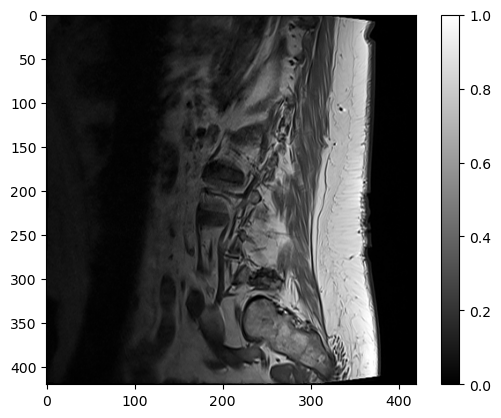

In [13]:
train_features, train_labels = next(iter(trainDataloader))
print(f"Feature batch: {train_features[0].shape}")
print(f"Labels batch: {train_labels[0]}")
img = train_features[0].squeeze()
label = train_labels[0]

fig, ax = plt.subplots()
im = ax.imshow(img, cmap='gray')
fig.colorbar(im, orientation='vertical')
plt.show()

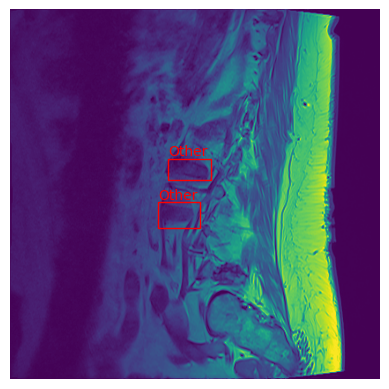

In [14]:
def plotImageWithAnnot(im, target, filename=None):
    fig, ax = plt.subplots()
    ax.imshow(im)
    plt.axis('off')

    for idx,b in enumerate(target["boxes"]):
        b = b.numpy()
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if isinstance(target["labels"], torch.Tensor):
            plt.text(b[0], b[1]-4, IntToClass[target["labels"].numpy()[idx]], {"color":"red"})
        else:
            plt.text(b[0], b[1]-4, IntToClass[target["labels"][idx]], {"color":"red"})
    if filename:
        plt.title(filename)
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f"objDetExamples/{filename}.png"), dpi=120)
        plt.close()
    else:
        plt.show()

plotImageWithAnnot(img, train_labels[0])

In [15]:
def filterPredictions(targets, threshold=0.5):
    newTargets=[]
    for t in targets:
        newTarget = {"boxes": [], "labels": [], "scores": []}
        for i,score in enumerate(t["scores"]):
            if score>threshold:
                newTarget["boxes"].append(t["boxes"][i])
                newTarget["labels"].append(t["labels"][i].item())
                newTarget["scores"].append(score.item())
        newTarget["labels"] = torch.tensor(newTarget["labels"])
        newTarget["scores"] = torch.tensor(newTarget["scores"])
        newTargets.append(newTarget)
    return newTargets

## Model

In [16]:
import torchvision
import torch
from functools import partial
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead, RetinaNet
from torchvision.models.mobilenetv2 import MobileNet_V2_Weights
from torchvision.models.detection.anchor_utils import AnchorGenerator

def create_model(num_classes):
    model = torchvision.models.detection.retinanet_resnet50_fpn_v2(
        weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1
    )
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256,
        num_anchors=num_anchors,
        num_classes=num_classes,
        norm_layer=partial(torch.nn.GroupNorm, 32)
    )
    return model



model = create_model(len(CLASSES))
# model.eval()
# x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
# predictions = model(x)
# print(predictions)
model.to(device)

RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [17]:
import math
from torchmetrics.detection import MeanAveragePrecision, IntersectionOverUnion
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

log_dir = "./logsVertebraeDet/" + "retinanet50Binary" +"_"+str(IMG_SIZE) + "/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)

num_epochs = 1000
earlyStoppingPatience=5
printFreq=3
saveFrequency=5


optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# params = [p for p in model.parameters() if p.requires_grad]
# optimizer = torch.optim.SGD(
#     params,
#     lr=0.005,
#     momentum=0.9,
#     weight_decay=0.0005
# )
# Decrease LR every step_size epochs by factor gamma
# globalLrScheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=3, T_mult=2, eta_min=1e-5 )
# globalLrScheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=3,
#     gamma=0.5
# )

metricIoUVal=IntersectionOverUnion(box_format="xyxy", class_metrics=True).to(device)
metricVal=MeanAveragePrecision(box_format="xyxy", class_metrics=True).to(device)

scaler = torch.amp.GradScaler(enabled=True)

def train(model, optimizer, data_loader, device, epoch, scaler=None):
    size = len(data_loader.dataset)
    model.train()
    print( f"\nEpoch: {epoch+1}")

    lr_scheduler = None
    if epoch == 0:
        # Warm up learning rate by going from 0.001 to 1*init_LR during the first epoch
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for step, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        
        # Handle null instances (images with no objects)
        for target in targets:
            if len(target['boxes']) == 0:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32).to(device)
                target['labels'] = torch.zeros((0,), dtype=torch.int64).to(device)

        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        losses_reduced = sum(loss for loss in loss_dict.values())

        lossValue = losses_reduced.item()
        
        if step%printFreq ==0:
            print(f"{lossValue}")
            summary_writer.add_scalar("Loss", lossValue, epoch*size//BATCH_SIZE+step)

        if not math.isfinite(lossValue):
            print(f"Loss is {lossValue}, stopping training")
            print(loss_dict)
            raise Exception()

        optimizer.zero_grad()
        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            optimizer.step()

        if lr_scheduler is not None:
            lr_scheduler.step()

@torch.no_grad()
def evaluate(model, data_loader_val, device, epoch):
    sizeVal = len(data_loader_val.dataset)
    model.eval()

    for stepVal, (imagesVal, targetsVal) in enumerate(data_loader_val):
        imagesVal = list(image.to(device) for image in imagesVal)
        
        # Handle null instances (images with no objects)
        for target in targetsVal:
            if len(target['boxes']) == 0:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32).to(device)
                target['labels'] = torch.zeros((0,), dtype=torch.int64).to(device)

        targetsCuda = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targetsVal]
        
        predsVal = model(imagesVal)
        predsCpu = [{k: v.detach().cpu() if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in predsVal]
        predsCpu = filterPredictions(predsCpu)
        if stepVal%printFreq ==0:
            plotImageWithAnnot(imagesVal[0].detach().cpu().numpy()[0,:,:], predsCpu[0], f"epoch{epoch}_step{stepVal}")

        metricVal.update(predsVal, targetsCuda)
        metricIoUVal.update(predsVal, targetsCuda)

    resultsmAP = metricVal.compute()
    resultsIoU = metricIoUVal.compute()
    print(f"Validation Metrics: {resultsmAP}\n{resultsIoU}")
    summary_writer.add_scalar("Val mAP", resultsmAP["map"], epoch)
    summary_writer.add_scalar("Val mAP50", resultsmAP["map_50"], epoch)
    summary_writer.add_scalar("Val mAP75", resultsmAP["map_75"], epoch)
    summary_writer.add_scalar("Val IoU", resultsIoU["iou"], epoch)
    for i in range(len(CLASSES)):
        summary_writer.add_scalar(f"Val mAP_{IntToClass[i]}", resultsmAP["map_per_class"][0], epoch)
        summary_writer.add_scalar(f"Val IoU_{IntToClass[i]}", resultsIoU[f"iou/cl_{i}"], epoch)

    return resultsmAP["map"].detach().cpu().numpy()

bestMap=0
bestEpoch=0
bestWeights=None

for epoch in range(num_epochs):
    train(model, optimizer, trainDataloader, device, epoch, scaler=scaler)
    valMap = evaluate(model, valDataloader, device, epoch)

    # print(f"Last LR: {globalLrScheduler.get_last_lr()}")
    # globalLrScheduler.step()

    if epoch%saveFrequency==0:
        torch.save(model, os.path.join(DATA_PATH, f'VertebraeDetectorBinary_epoch{epoch}_mAP{bestMap:.4f}.pth'))
   
    if valMap>bestMap:
        bestMap=valMap
        bestEpoch=epoch
        bestWeights = deepcopy(model.state_dict())
        print(f"New best MAP: {bestMap:.5f}")
    if epoch-bestEpoch>earlyStoppingPatience:
        print("Early Stopping")
        print(model.load_state_dict(bestWeights))
        break
    
print("Done!")


Epoch: 1
1.406484603881836
1.3137691020965576
1.1050686836242676
0.8762608170509338


c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)  # noqa: B028


Validation Metrics: {'map': tensor(0.2483), 'map_50': tensor(0.4638), 'map_75': tensor(0.2435), 'map_small': tensor(0.2207), 'map_medium': tensor(0.2520), 'map_large': tensor(-1.), 'mar_1': tensor(0.1625), 'mar_10': tensor(0.4919), 'mar_100': tensor(0.5339), 'mar_small': tensor(0.2976), 'mar_medium': tensor(0.5452), 'mar_large': tensor(-1.), 'map_per_class': tensor([0.0784, 0.4181]), 'mar_100_per_class': tensor([0.4547, 0.6130]), 'classes': tensor([0, 1], dtype=torch.int32)}
{'iou': tensor(0.0396, device='cuda:0'), 'iou/cl_0': tensor(0.1030, device='cuda:0'), 'iou/cl_1': tensor(0.0389, device='cuda:0')}
New best MAP: 0.24826

Epoch: 2
0.7132898569107056
0.6187732219696045
0.5360647439956665
0.4969182312488556
Validation Metrics: {'map': tensor(0.3299), 'map_50': tensor(0.5687), 'map_75': tensor(0.3550), 'map_small': tensor(0.3270), 'map_medium': tensor(0.3366), 'map_large': tensor(-1.), 'mar_1': tensor(0.2511), 'mar_10': tensor(0.5706), 'mar_100': tensor(0.5955), 'mar_small': tensor(0.

In [18]:
#TODO:
# Augmentation with Albumentations


In [20]:
bestEpoch

152

In [19]:
torch.save(model, os.path.join(DATA_PATH, f'VertebraeDetectorBinary_epoch{bestEpoch}_mAP{bestMap:.4f}.pth'))